# Лабораторная работа №4. Ценовая стратегия AI-сервиса

Кейс «AI-Копирайтер». Части 1–4: метрики, прибыль и NPV, чувствительность, рекомендации.


## Допущения

1. ARPU = Цена × Конверсия (доход на всего привлечённого пользователя).
2. LTV = ARPU / Churn; срок жизни = 1 / Churn, месяцев.
3. Диапазонные цены — середина: Динамическая 1250 руб., Персонализированная 2650 руб.
4. CAC — на привлечённого пользователя; в модели прибыли смешанный CAC = 800 руб. (30 % реклама / 40 % контент-маркетинг / 30 % виральный).
5. Рост 100/50/20 % — нетто-прирост базы; валовое привлечение = прирост + отток.
6. NPV: разработка 15 млн руб. в t = 0; ставка 12 % приведена к месячной.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

MARKET_SIZE = 500_000
MARKET_GROWTH = 0.25
DEV_COST = 15_000_000
MONTHLY_FIXED = 2_000_000

CAC_ADS = 1_500
CAC_CONTENT = 800
CAC_VIRAL = 100

CHANNEL_MIX = {'Реклама': 0.30, 'Контент-маркетинг/SEO': 0.40, 'Виральный рост': 0.30}
CHANNEL_CACS = {'Реклама': CAC_ADS, 'Контент-маркетинг/SEO': CAC_CONTENT, 'Виральный рост': CAC_VIRAL}
CAC_BLENDED = sum(CHANNEL_MIX[name] * cac for name, cac in CHANNEL_CACS.items())

RATE = 0.12
RATE_MONTH = (1 + RATE) ** (1 / 12) - 1

N0 = 1_000
GROWTH_BY_YEAR = {1: 1.00, 2: 0.50, 3: 0.20}
HORIZON = 36


def money(value):
    return f'{value:,.0f} руб.'.replace(',', ' ')


def users(value):
    return f'{value:,.0f}'.replace(',', ' ')


print(f'Смешанный CAC: {money(CAC_BLENDED)} | месячная ставка: {RATE_MONTH:.4%}')


Смешанный CAC: 800 руб. | месячная ставка: 0.9489%


## Часть 1. Ключевые метрики


In [2]:
strategies = pd.DataFrame([
    {'Стратегия': 'Freemium',            'Цена_мин': 2000, 'Цена_макс': 2000, 'Конверсия': 0.02, 'Churn': 0.08},
    {'Стратегия': 'Подписка',            'Цена_мин': 1500, 'Цена_макс': 1500, 'Конверсия': 0.20, 'Churn': 0.05},
    {'Стратегия': 'Динамическая',        'Цена_мин': 500,  'Цена_макс': 2000, 'Конверсия': 0.15, 'Churn': 0.06},
    {'Стратегия': 'Персонализированная', 'Цена_мин': 300,  'Цена_макс': 5000, 'Конверсия': 0.12, 'Churn': 0.04},
])

strategies['Цена'] = (strategies['Цена_мин'] + strategies['Цена_макс']) / 2
strategies['ARPU'] = strategies['Цена'] * strategies['Конверсия']
strategies['Срок_жизни_мес'] = 1 / strategies['Churn']
strategies['LTV'] = strategies['ARPU'] / strategies['Churn']

metrics = strategies[['Стратегия', 'Цена_мин', 'Цена_макс', 'Цена', 'Конверсия', 'Churn',
                      'ARPU', 'Срок_жизни_мес', 'LTV']].copy()
metrics['Конверсия'] = metrics['Конверсия'].map(lambda v: f'{v:.0%}')
metrics['Churn'] = metrics['Churn'].map(lambda v: f'{v:.0%}')
metrics['Срок_жизни_мес'] = metrics['Срок_жизни_мес'].map(lambda v: f'{v:.1f}')
display(metrics)

best_ltv = strategies.loc[strategies['LTV'].idxmax()]
print(f"Лидер по LTV: {best_ltv['Стратегия']} — {money(best_ltv['LTV'])}")


,Стратегия,Цена_мин,Цена_макс,Цена,Конверсия,Churn,ARPU,Срок_жизни_мес,LTV
0,Freemium,2000,2000,"2,000.00",2%,8%,40.00,12.5,500.00
1,Подписка,1500,1500,"1,500.00",20%,5%,300.00,20.0,"6,000.00"
2,Динамическая,500,2000,"1,250.00",15%,6%,187.50,16.7,"3,125.00"
3,Персонализированная,300,5000,"2,650.00",12%,4%,318.00,25.0,"7,950.00"


Лидер по LTV: Персонализированная — 7 950 руб.


LTV/CAC по каналам. Порог 3,0.


In [3]:
ltv_cac = pd.DataFrame({'Стратегия': strategies['Стратегия'], 'LTV': strategies['LTV']})
for name, cac in CHANNEL_CACS.items():
    ltv_cac[f'LTV/CAC · {name}'] = strategies['LTV'] / cac
ltv_cac['LTV/CAC · смешанный'] = strategies['LTV'] / CAC_BLENDED

ltv_cac_display = ltv_cac.copy()
ltv_cac_display['LTV'] = ltv_cac_display['LTV'].map(money)
for column in ltv_cac_display.columns[2:]:
    ltv_cac_display[column] = ltv_cac_display[column].map(lambda v: f'{v:.2f}')
display(ltv_cac_display)

passing = [row['Стратегия'] for _, row in ltv_cac.iterrows()
           if row['LTV/CAC · смешанный'] >= 3]
print('Порог 3,0 проходят:', ', '.join(passing))


,Стратегия,LTV,LTV/CAC · Реклама,LTV/CAC · Контент-маркетинг/SEO,LTV/CAC · Виральный рост,LTV/CAC · смешанный
0,Freemium,500 руб.,0.33,0.62,5.00,0.62
1,Подписка,6 000 руб.,4.00,7.50,60.00,7.50
2,Динамическая,3 125 руб.,2.08,3.91,31.25,3.91
3,Персонализированная,7 950 руб.,5.30,9.94,79.50,9.94


Порог 3,0 проходят: Подписка, Динамическая, Персонализированная


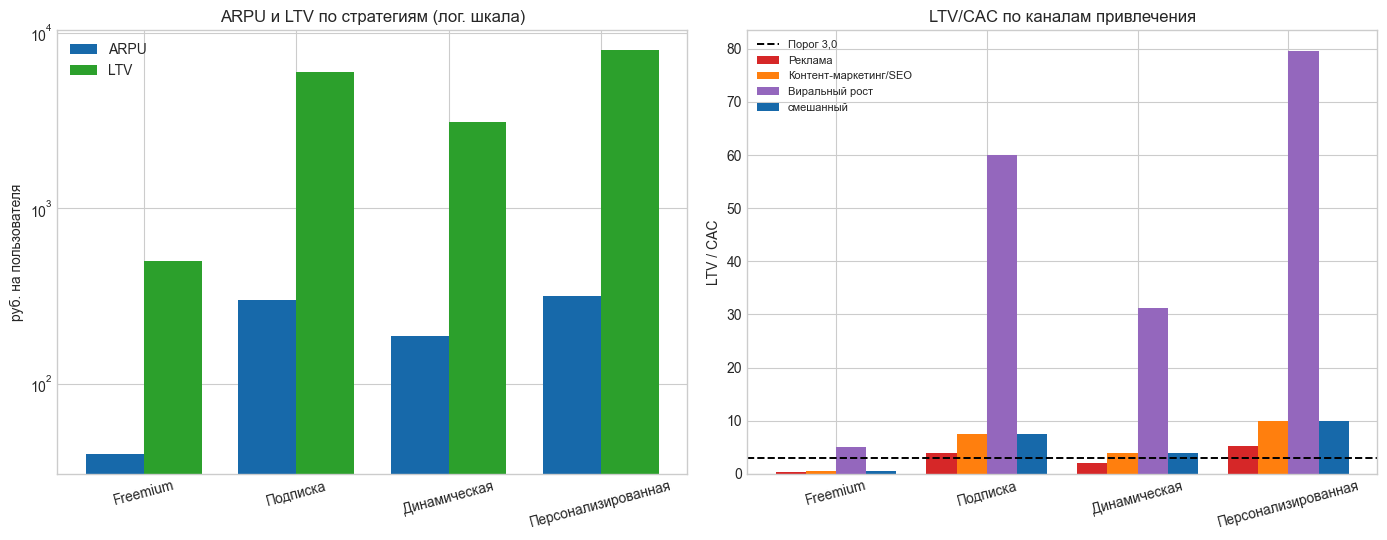

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

positions = np.arange(len(strategies))
width = 0.38
axes[0].bar(positions - width / 2, strategies['ARPU'], width, color='#1769aa', label='ARPU')
axes[0].bar(positions + width / 2, strategies['LTV'], width, color='#2ca02c', label='LTV')
axes[0].set_yscale('log')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(strategies['Стратегия'], rotation=15)
axes[0].set_title('ARPU и LTV по стратегиям (лог. шкала)')
axes[0].set_ylabel('руб. на пользователя')
axes[0].legend()

ratio_columns = [c for c in ltv_cac.columns if c.startswith('LTV/CAC')]
x = np.arange(len(strategies))
bar_width = 0.2
colors = ['#d62728', '#ff7f0e', '#9467bd', '#1769aa']
for index, column in enumerate(ratio_columns):
    axes[1].bar(x + (index - 1.5) * bar_width, ltv_cac[column], bar_width,
                label=column.replace('LTV/CAC · ', ''), color=colors[index])
axes[1].axhline(3, color='black', linestyle='--', linewidth=1.4, label='Порог 3,0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(strategies['Стратегия'], rotation=15)
axes[1].set_title('LTV/CAC по каналам привлечения')
axes[1].set_ylabel('LTV / CAC')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Часть 2. Прибыль и NPV за 3 года

База: 1 000 → 2 000 → 3 000 → 3 600 (нетто-прирост 100/50/20 %). Внутри года — геометрический рост. Валовое привлечение = прирост базы + отток.

NPV = Σ Прибыль / (1 + r)ᵐ − 15 000 000.


In [5]:
def user_targets(horizon=HORIZON, n0=N0):
    targets = []
    start = float(n0)
    for year in (1, 2, 3):
        end = start * (1 + GROWTH_BY_YEAR[year])
        for month in range(1, 13):
            share = month / 12
            targets.append(start * (end / start) ** share)
        start = end
    return np.array(targets[:horizon])


TARGETS = user_targets()


def simulate(conversion, churn, cac, price, horizon=HORIZON, n0=N0):
    targets = user_targets(horizon, n0)
    previous = float(n0)
    rows = []
    for month in range(1, horizon + 1):
        end = targets[month - 1]
        churned = churn * previous
        gross_adds = max((end - previous) + churned, 0)
        average_base = (previous + end) / 2
        revenue = price * conversion * average_base
        costs = MONTHLY_FIXED + cac * gross_adds
        profit = revenue - costs
        discount_factor = 1 / (1 + RATE_MONTH) ** month
        rows.append({
            'Месяц': month,
            'Год': (month - 1) // 12 + 1,
            'База_начало': previous,
            'База_конец': end,
            'Отток': churned,
            'Привлечено': gross_adds,
            'Выручка': revenue,
            'Затраты': costs,
            'Прибыль': profit,
            'Коэффициент_дисконтирования': discount_factor,
            'PV_прибыли': profit * discount_factor,
        })
        previous = end
    return pd.DataFrame(rows)


def npv(projection, dev_cost=DEV_COST):
    return float(projection['PV_прибыли'].sum()) - dev_cost


projections = {}
for _, row in strategies.iterrows():
    projections[row['Стратегия']] = simulate(row['Конверсия'], row['Churn'], CAC_BLENDED, row['Цена'])

print(f'База: 12 мес. — {users(TARGETS[11])}; 24 мес. — {users(TARGETS[23])}; 36 мес. — {users(TARGETS[35])}')


База: 12 мес. — 2 000; 24 мес. — 3 000; 36 мес. — 3 600


In [6]:
profit_table = []
for _, row in strategies.iterrows():
    projection = projections[row['Стратегия']]
    profit_table.append({
        'Стратегия': row['Стратегия'],
        'Выручка за 3 года': projection['Выручка'].sum(),
        'Затраты на привлечение': (CAC_BLENDED * projection['Привлечено']).sum(),
        'Постоянные затраты': MONTHLY_FIXED * HORIZON,
        'Прибыль за 3 года': projection['Прибыль'].sum(),
        'NPV (с разработкой)': npv(projection),
    })
profit_table = pd.DataFrame(profit_table).sort_values('NPV (с разработкой)', ascending=False)

profit_display = profit_table.copy()
for column in profit_display.columns[1:]:
    profit_display[column] = profit_display[column].map(money)
display(profit_display)

by_year = pd.DataFrame({
    name: projection.groupby('Год')['Прибыль'].sum()
    for name, projection in projections.items()
}) / 1_000_000
display(by_year.round(2).rename_axis('Год, млн руб.'))

top = profit_table.iloc[0]
runner = profit_table.iloc[1]
print(f"Лучший NPV: {top['Стратегия']} ({money(top['NPV (с разработкой)'])}); "
      f"отрыв от «{runner['Стратегия']}»: {money(top['NPV (с разработкой)'] - runner['NPV (с разработкой)'])}")


,Стратегия,Выручка за 3 года,Затраты на привлечение,Постоянные затраты,Прибыль за 3 года,NPV (с разработкой)
3,Персонализированная,27 477 438 руб.,4 803 425 руб.,72 000 000 руб.,-49 325 987 руб.,-57 317 742 руб.
1,Подписка,25 922 111 руб.,5 484 282 руб.,72 000 000 руб.,-51 562 170 руб.,-59 142 781 руб.
2,Динамическая,16 201 320 руб.,6 165 138 руб.,72 000 000 руб.,-61 963 818 руб.,-67 633 428 руб.
0,Freemium,3 456 282 руб.,7 526 850 руб.,72 000 000 руб.,-76 070 569 руб.,-79 148 218 руб.


,Freemium,Подписка,Динамическая,Персонализированная
"Год, млн руб.",,,,
1,-25.18,-20.28,-22.36,-19.83
2,-25.48,-17.08,-20.65,-16.32
3,-25.41,-14.20,-18.96,-13.18


Лучший NPV: Персонализированная (-57 317 742 руб.); отрыв от «Подписка»: 1 825 039 руб.


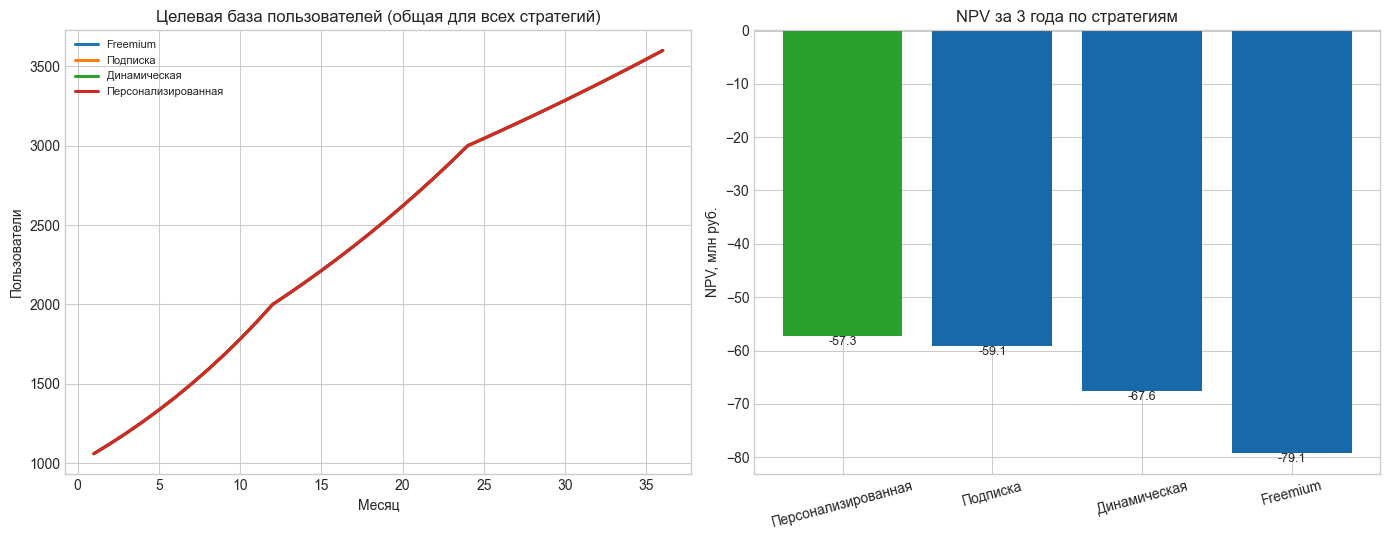

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, projection in projections.items():
    axes[0].plot(projection['Месяц'], projection['База_конец'], linewidth=2.2, label=name)
axes[0].set_title('Целевая база пользователей (общая для всех стратегий)')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Пользователи')
axes[0].legend(fontsize=8)

ordered = profit_table.set_index('Стратегия')['NPV (с разработкой)']
bar_colors = ['#2ca02c' if value == ordered.max() else '#1769aa' for value in ordered]
axes[1].bar(ordered.index, ordered / 1_000_000, color=bar_colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('NPV за 3 года по стратегиям')
axes[1].set_ylabel('NPV, млн руб.')
axes[1].tick_params(axis='x', rotation=15)
for index, value in enumerate(ordered):
    axes[1].text(index, value / 1_000_000, f'{value / 1_000_000:,.1f}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()


## Часть 3. Чувствительность ±30 %

Меняется один параметр, остальные — базовые. LTV/CAC = (Цена × Конверсия) / (Churn × CAC), значит относительная чувствительность у всех стратегий одинакова; различается абсолютный запас прочности.


In [8]:
def ltv_cac_ratio(conversion, churn, price, cac):
    return (price * conversion / churn) / cac


sensitivity_rows = []
for _, row in strategies.iterrows():
    base_npv = npv(projections[row['Стратегия']])
    base_ratio = ltv_cac_ratio(row['Конверсия'], row['Churn'], row['Цена'], CAC_BLENDED)
    for parameter in ('Конверсия', 'Churn', 'CAC'):
        for shift in (-0.30, 0.30):
            conversion, churn, cac = row['Конверсия'], row['Churn'], CAC_BLENDED
            if parameter == 'Конверсия':
                conversion *= (1 + shift)
            elif parameter == 'Churn':
                churn *= (1 + shift)
            else:
                cac *= (1 + shift)
            projection = simulate(conversion, churn, cac, row['Цена'])
            ratio = ltv_cac_ratio(conversion, churn, row['Цена'], cac)
            sensitivity_rows.append({
                'Стратегия': row['Стратегия'],
                'Параметр': parameter,
                'Изменение': f'{shift:+.0%}',
                'NPV': npv(projection),
                'LTV/CAC': ratio,
                'Δ NPV к базе': npv(projection) - base_npv,
                'Δ LTV/CAC к базе': ratio - base_ratio,
            })

sensitivity = pd.DataFrame(sensitivity_rows)

npv_pivot = sensitivity.pivot_table(index='Стратегия', columns=['Параметр', 'Изменение'],
                                    values='NPV') / 1_000_000
npv_pivot.columns = [f'{parameter} {shift}' for parameter, shift in npv_pivot.columns]
display(npv_pivot.round(1).rename(columns=lambda c: f'NPV, млн руб. · {c}'))


,"NPV, млн руб. · CAC +30%","NPV, млн руб. · CAC -30%","NPV, млн руб. · Churn +30%","NPV, млн руб. · Churn -30%","NPV, млн руб. · Конверсия +30%","NPV, млн руб. · Конверсия -30%"
Стратегия,,,,,,
Freemium,-81.00,-77.30,-80.50,-77.80,-78.30,-80.00
Динамическая,-69.20,-66.10,-68.60,-66.60,-63.70,-71.60
Персонализированная,-58.50,-56.10,-58.00,-56.70,-50.60,-64.00
Подписка,-60.50,-57.80,-60.00,-58.30,-52.80,-65.50


In [9]:
robust_rows = []
for _, row in strategies.iterrows():
    subset = sensitivity[sensitivity['Стратегия'] == row['Стратегия']]
    base_ratio = ltv_cac_ratio(row['Конверсия'], row['Churn'], row['Цена'], CAC_BLENDED)
    worst_ratio = subset['LTV/CAC'].min()
    robust_rows.append({
        'Стратегия': row['Стратегия'],
        'Базовый NPV': npv(projections[row['Стратегия']]),
        'Худший NPV': subset['NPV'].min(),
        'Размах NPV': subset['NPV'].max() - subset['NPV'].min(),
        'Базовый LTV/CAC': base_ratio,
        'Худший LTV/CAC': worst_ratio,
        'Запас над порогом 3,0': worst_ratio - 3,
    })
robustness = pd.DataFrame(robust_rows).sort_values('Худший LTV/CAC', ascending=False).reset_index(drop=True)
robustness.insert(0, 'Ранг', robustness.index + 1)

robustness_display = robustness.copy()
for column in ['Базовый NPV', 'Худший NPV', 'Размах NPV']:
    robustness_display[column] = robustness_display[column].map(lambda v: f'{v / 1_000_000:,.1f} млн')
for column in ['Базовый LTV/CAC', 'Худший LTV/CAC', 'Запас над порогом 3,0']:
    robustness_display[column] = robustness_display[column].map(lambda v: f'{v:.2f}')
display(robustness_display)

above = robustness[robustness['Худший LTV/CAC'] >= 3]
print(f"Устойчивее всех: {robustness.iloc[0]['Стратегия']} (худший LTV/CAC {robustness.iloc[0]['Худший LTV/CAC']:.2f}).")
print('Порог 3,0 держат при любом отклонении: ' + ', '.join(above['Стратегия']) + '.')


,Ранг,Стратегия,Базовый NPV,Худший NPV,Размах NPV,Базовый LTV/CAC,Худший LTV/CAC,"Запас над порогом 3,0"
0,1,Персонализированная,-57.3 млн,-64.0 млн,13.5 млн,9.94,6.96,3.96
1,2,Подписка,-59.1 млн,-65.5 млн,12.7 млн,7.50,5.25,2.25
2,3,Динамическая,-67.6 млн,-71.6 млн,7.9 млн,3.91,2.73,-0.27
3,4,Freemium,-79.1 млн,-81.0 млн,3.7 млн,0.62,0.44,-2.56


Устойчивее всех: Персонализированная (худший LTV/CAC 6.96).
Порог 3,0 держат при любом отклонении: Персонализированная, Подписка.


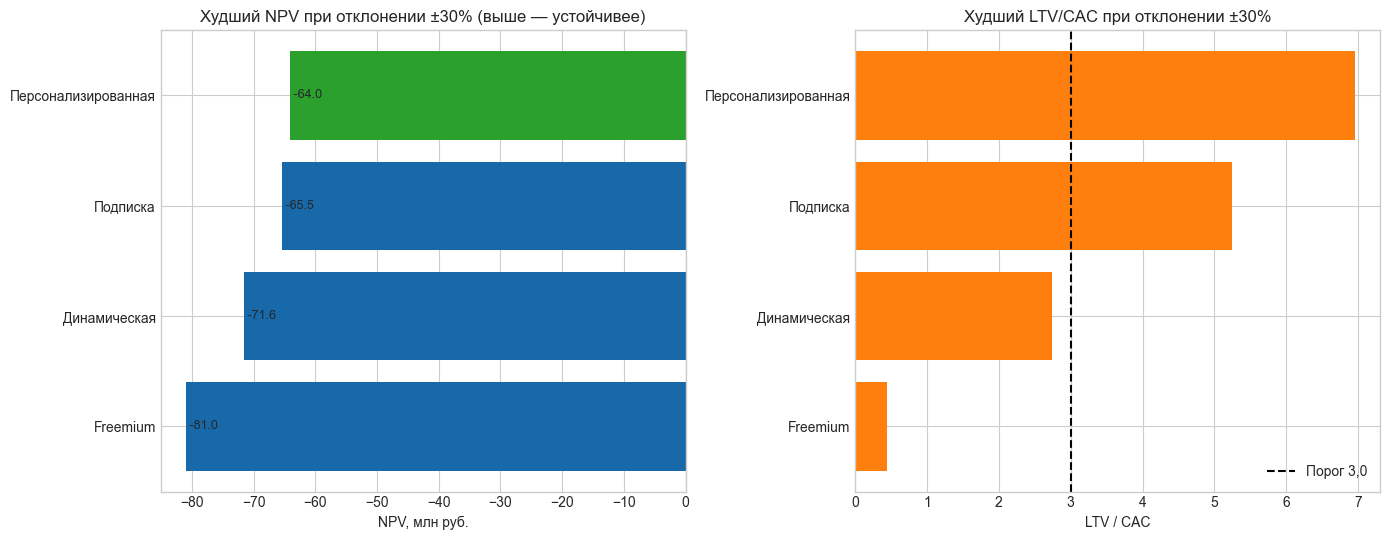

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = robustness['Стратегия']
worst_npv = robustness['Худший NPV'] / 1_000_000
colors = ['#2ca02c' if index == 0 else '#1769aa' for index in range(len(order))]
axes[0].barh(order, worst_npv, color=colors)
axes[0].set_title('Худший NPV при отклонении ±30% (выше — устойчивее)')
axes[0].set_xlabel('NPV, млн руб.')
axes[0].invert_yaxis()
for index, value in enumerate(worst_npv):
    axes[0].text(value, index, f' {value:,.1f}', va='center', fontsize=9)

axes[1].barh(order, robustness['Худший LTV/CAC'], color='#ff7f0e')
axes[1].axvline(3, color='black', linestyle='--', linewidth=1.5, label='Порог 3,0')
axes[1].set_title('Худший LTV/CAC при отклонении ±30%')
axes[1].set_xlabel('LTV / CAC')
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()


## Часть 4. Рекомендации

Ни одна стратегия не окупается за 3 года: 24 млн руб./год постоянных затрат против базы 3 600. Выбор — по LTV/CAC и порогу окупаемости.


In [11]:
break_even_rows = []
for _, row in strategies.iterrows():
    contribution = row['ARPU'] - CAC_BLENDED * row['Churn']
    if contribution > 0:
        breakeven_users = MONTHLY_FIXED / contribution
        break_even_rows.append({
            'Стратегия': row['Стратегия'],
            'Вклад с пользователя, руб./мес.': f'{contribution:,.1f}',
            'Порог базы, чел.': users(breakeven_users),
            'Бюджет привлечения': money(breakeven_users * CAC_BLENDED),
        })
    else:
        break_even_rows.append({
            'Стратегия': row['Стратегия'],
            'Вклад с пользователя, руб./мес.': f'{contribution:,.1f}',
            'Порог базы, чел.': 'недостижим',
            'Бюджет привлечения': '—',
        })
break_even = pd.DataFrame(break_even_rows).sort_values(
    'Вклад с пользователя, руб./мес.', ascending=False, key=lambda s: s.str.replace(',', '').astype(float))
display(break_even)

personalized = strategies.loc[strategies['Стратегия'] == 'Персонализированная'].iloc[0]
threshold = MONTHLY_FIXED / (personalized['ARPU'] - CAC_BLENDED * personalized['Churn'])
print(f'Порог окупаемости лидера: {users(threshold)} чел. при базе 36 мес. {users(TARGETS[35])} чел.')


,Стратегия,"Вклад с пользователя, руб./мес.","Порог базы, чел.",Бюджет привлечения
3,Персонализированная,286.0,6 993,5 594 406 руб.
1,Подписка,260.0,7 692,6 153 846 руб.
2,Динамическая,139.5,14 337,11 469 534 руб.
0,Freemium,-24.0,недостижим,—


Порог окупаемости лидера: 6 993 чел. при базе 36 мес. 3 600 чел.


### Выбор: Персонализированная (гибрид подписки и value-based)

| Критерий | Персонализированная | Подписка | Динамическая | Freemium |
|---|---|---|---|---|
| ARPU, руб. | **318** | 300 | 188 | 40 |
| LTV, руб. | **7 950** | 6 000 | 3 125 | 500 |
| LTV/CAC (смеш.) | **9,94** | 7,50 | 3,91 | 0,62 |
| Худший NPV, млн | **−64,0** | −65,5 | −71,6 | −81,0 |
| Порог базы, чел. | **6 993** | 7 692 | 14 337 | недостижим |

Причины: максимум ARPU, LTV и LTV/CAC; минимальный порог окупаемости; минимальный churn (4 %); лучший запас при ±30 %. Freemium нежизнеспособен: LTV ниже CAC по всем каналам, кроме вирального.

**Цены:** массовый 1 500–2 000 руб./мес.; профессиональный 3 000–5 000; агентский/enterprise от 5 000 (API, SLA). Играть в верхнем сегменте, не в минимальной цене.

### Коммуникации
- Позиционирование: «AI-копирайтер, который знает ваш бренд».
- Сегменты: предприниматели — «текст за 5 минут»; маркетинг/SMM — «пакет контента и SEO»; агентства — «white label и API».
- Каналы: контент+SEO (CAC 800) как основа, реклама (1 500) точечно, виральный контур (100) обязательно.

### Дорожная карта

| Этап | Срок | Действия |
|---|---|---|
| Подготовка | 0–2 мес. | Анализ цен, пилот тарифов, продуктовая аналитика |
| Пилот | 2–6 мес. | 3 варианта цены на когортах, замер конверсии и churn |
| Запуск | 6–12 мес. | Открытый выход, контент+SEO, партнёрства, реферальная программа |
| Масштабирование | 12–36 мес. | Рост до порога ~7 000 пользователей, enterprise |

### KPI
LTV/CAC по каналам ≥ 3; ARPU и конверсия по когортам; churn ≤ 4–5 %/мес; blended CAC ≤ 800 руб.; расстояние до порога окупаемости.

### Риски и митигация

| Риск | Меры |
|---|---|
| Низкая готовность платить | Ценовые A/B-тесты, premium-якорь, годовая предоплата |
| Высокий churn | Онбординг, шаблоны задач, удержание по использованию |
| Рост стоимости рекламы | Сдвиг в контент/SEO и виральные механики, реферальная программа |
| Демпинг конкурентов | Конкурировать качеством и интеграциями, не ценой |
| Фиксированные затраты давят маржу | Ревизия облака, поэтапная инфраструктура, рост базы |
| Данные и авторские права | Комплаенс, фильтрация контента, прозрачные условия |

**Итог.** При базе 1 000 пользователей окупаемость за 3 года недостижима ни при одной цене. Оптимум — персонализированная гибридная модель: максимальные ARPU, LTV, LTV/CAC и запас прочности, минимальный порог окупаемости. До порога проект — venture-инвестиция, не самоокупаемый бизнес.


In [12]:
final_summary = pd.DataFrame({
    'Стратегия': strategies['Стратегия'],
    'ARPU, руб.': strategies['ARPU'].map(lambda v: f'{v:,.1f}'),
    'LTV, руб.': strategies['LTV'].map(lambda v: f'{v:,.0f}'),
    'LTV/CAC': (strategies['LTV'] / CAC_BLENDED).map(lambda v: f'{v:.2f}'),
    'NPV за 3 года': profit_table.set_index('Стратегия').loc[
        strategies['Стратегия'], 'NPV (с разработкой)'].map(money).values,
})
display(final_summary)


,Стратегия,"ARPU, руб.","LTV, руб.",LTV/CAC,NPV за 3 года
0,Freemium,40.0,500,0.62,-79 148 218 руб.
1,Подписка,300.0,"6,000",7.50,-59 142 781 руб.
2,Динамическая,187.5,"3,125",3.91,-67 633 428 руб.
3,Персонализированная,318.0,"7,950",9.94,-57 317 742 руб.
